# 0304 淺度機器學習：Principal Component Analysis (PCA)

**Raw data ($N$ samples, $p$ variables)**: $x_1, x_2, \dots, x_p \rightarrow \text{ML (Black box)} \rightarrow \text{output}$

## 1. Problems
1. $p, N$ 很大造成計算問題。
2. $x_1, x_2, \dots$ 可能彼此相關（線性），導致觀察到彼此重疊 ($Cov(x_i, x_j) \neq 0$)。

## 2. Solutions
1. 重組變數 $z_1, z_2, \dots, z_p$ 使得彼此不相關。
2. 訊息量重新分配：$\sigma^2_{z_1} \ge \sigma^2_{z_2} \ge \dots \ge \sigma^2_{z_p}$ （以變數之變異數當作「訊息量」）。

---
## 3. Linear Transformation

$x_1, x_2, \dots, x_p \xrightarrow{\text{Linear Transformation}} z_1, z_2, \dots, z_p$

將新變數 $z_i$ 表示為原始變數的線性組合（其中 $\alpha_{ij}$ 為組合係數）：

$$
\begin{aligned}
z_1 &= \alpha_{11} x_1 + \alpha_{12} x_2 + \dots + \alpha_{1p} x_p \\
z_2 &= \alpha_{21} x_1 + \alpha_{22} x_2 + \dots + \alpha_{2p} x_p \\
&\vdots \\
z_p &= \alpha_{p1} x_1 + \alpha_{p2} x_2 + \dots + \alpha_{pp} x_p
\end{aligned}
$$

---
## 4. Covariance & Information (Variance)

確保新變數之間不相關：
$$Cov(z_i, z_j) = 0, \quad i \neq j$$

推導過程：
$$
\begin{aligned}
Cov(z_i, z_j) &= E[(z_i - E(z_i))(z_j - E(z_j))] = 0 \\
&\Rightarrow E(z_i z_j) = E(z_i)E(z_j)
\end{aligned}
$$
*Assume $E(z_i) = E(z_j) = 0$, then $E(z_i z_j) = 0$*

主成份訊息量由大到小排序（變異數越小越可割捨）：
$$\sigma^2_{z_1} \ge \sigma^2_{z_2} \ge \dots \ge \sigma^2_{z_p}$$

---
## 5. Dimension Reduction

取 $z_1, z_2, \dots, z_q$ 等「大成分」的變數，捨去其他，達到降維目的。
Dimension from $p$ to $q$ (especially, $p \gg q$).

**New data ($N$ samples, $q$ variables)**: $z_1, z_2, \dots, z_q \rightarrow \text{ML}$

$$
\begin{aligned}
X_i^T &= [x_{i1}, x_{i2}, \dots, x_{ip}] \in \mathbb{R}^p, \quad i = 1, 2, \dots, N \\
Z_i^T &= [z_{i1}, z_{i2}, \dots, z_{iq}] \in \mathbb{R}^q
\end{aligned}
$$

**總訊息量不變：**
$$\sum_{j=1}^p \sigma^2_{x_j} = \sum_{k=1}^p \sigma^2_{z_k}$$

---
## 6. How it works? (Take two dimensions for example)


**How do we derive the new axis?** 
$\Rightarrow$ **The eigenvector of covariance matrix**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X = np.random.multivariate_normal([0, 0], [[5, 3], [3, 2]], 300)

cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

z1 = eigenvectors[:, 0]
z2 = eigenvectors[:, 1]

print("Covariance Matrix:\n", cov_matrix)
print("\nEigenvalues (Variance):\n", eigenvalues)
print("\nEigenvectors (New axes z1, z2):\n", eigenvectors)

Covariance Matrix:
 [[4.80549276 2.87284275]
 [2.87284275 1.90390591]]

Eigenvalues (Variance):
 [6.57308822 0.13631045]

Eigenvectors (New axes z1, z2):
 [[-0.85169904  0.52403124]
 [-0.52403124 -0.85169904]]


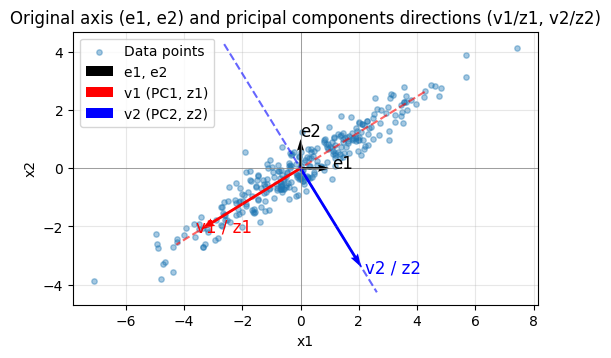

In [3]:
# 二維數據平面圖：原始座標軸 (e1, e2) 與主成份方向 (z1, z2)

fig, ax = plt.subplots(figsize=(6, 6))

# 繪製資料點（x1, x2）
ax.scatter(X[:, 0], X[:, 1], s=15, alpha=0.4, label='Data points')

# 原始座標軸的標準基底 e1, e2
origin = np.array([[0, 0]])
e1 = np.array([[1, 0]])  # x1 軸方向
[e1x, e1y] = e1[0]
e2 = np.array([[0, 1]])  # x2 軸方向
[e2x, e2y] = e2[0]

# 主成份方向的基底 v1, v2（對應 z1, z2）
v1 = z1  # 第一主成份方向
v2 = z2  # 第二主成份方向

# 放大向量以便於視覺化
scale = 4

# 畫出原本的基底 e1, e2
ax.quiver(0, 0, e1x, e1y, angles='xy', scale_units='xy', scale=1, color='black', width=0.005, label='e1, e2')
ax.quiver(0, 0, e2x, e2y, angles='xy', scale_units='xy', scale=1, color='black', width=0.005)

# 畫出主成份方向 v1, v2（z1, z2 的 basis）
ax.quiver(0, 0, scale * v1[0], scale * v1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.006, label='v1 (PC1, z1)')
ax.quiver(0, 0, scale * v2[0], scale * v2[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.006, label='v2 (PC2, z2)')

# 也畫出沿著主成份方向的直線，幫助理解「軸」
line_scale = np.linspace(-5, 5, 2)
line1 = np.outer(line_scale, v1)
line2 = np.outer(line_scale, v2)
ax.plot(line1[:, 0], line1[:, 1], 'r--', alpha=0.6)
ax.plot(line2[:, 0], line2[:, 1], 'b--', alpha=0.6)

# 標註文字
ax.text(1.1, 0, 'e1', fontsize=12, color='black')
ax.text(0, 1.1, 'e2', fontsize=12, color='black')
ax.text(scale * v1[0] * 1.05, scale * v1[1] * 1.05, 'v1 / z1', fontsize=12, color='red')
ax.text(scale * v2[0] * 1.05, scale * v2[1] * 1.05, 'v2 / z2', fontsize=12, color='blue')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Original axis (e1, e2) and pricipal components directions (v1/z1, v2/z2)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(alpha=0.3)
ax.set_aspect('equal', 'box')
ax.legend(loc='upper left')

plt.show()